# WEIGHTED ANCHORED DENSEST SUBGRAPH (WADS) = Part 2
### Algorithm Development & Implementation 

**Module:** COM713 Advanced Data Structures and Algorithms  


---

This notebook contains the **final working implementation** and explanation for the **Weighted Anchored Densest Subgraph (WADS)** greedy anchored-expansion algorithm.

**Dataset (download):** https://networkdata.ics.uci.edu/data/karate/  
(Alternative: the same Karate Club graph is available directly inside `networkx` as `nx.karate_club_graph()`.)


### 1. Pseudocode

```
S ← R
bestScore ← WADS(S)

while improvement exists:
    for each u in V \ S:
        compute WADS(S ∪ {u})
    add best improving u (if any)
return S, bestScore


## 2. Working Python Implementation

This section defines the graph class and the WADS solver.


In [3]:
from dataclasses import dataclass
from typing import Dict, List, Tuple, Set, Optional

@dataclass
class WeightedGraph:
    num_nodes: int
    def __post_init__(self):
        self.adj: Dict[int, List[Tuple[int, float]]] = {i: [] for i in range(self.num_nodes)}
        self.nodes: Set[int] = set(range(self.num_nodes))

    def add_edge(self, u: int, v: int, weight: float) -> None:
        if weight <= 0:
            raise ValueError('Edge weights must be positive.')
        self.adj[u].append((v, float(weight)))
        self.adj[v].append((u, float(weight)))

    def get_neighbours(self, u: int) -> List[Tuple[int, float]]:
        return self.adj[u]

    def weighted_degree(self, u: int) -> float:
        return sum(w for _, w in self.adj[u])

class WADSSolver:
    def __init__(self, graph: WeightedGraph, anchor_set: Set[int], lambda_param: float = 1.0):
        if lambda_param <= 0:
            raise ValueError('lambda_param must be > 0')
        self.graph = graph
        self.anchor_set = set(anchor_set)
        self.lambda_param = float(lambda_param)

    def compute_internal_weight(self, subgraph: Set[int]) -> float:
        internal_weight = 0.0
        for u in subgraph:
            for v, w in self.graph.get_neighbours(u):
                if v in subgraph and u < v:  # count each undirected edge once
                    internal_weight += w
        return internal_weight

    def compute_penalty(self, subgraph: Set[int]) -> float:
        penalty = 0.0
        for u in (subgraph - self.anchor_set):
            penalty += self.graph.weighted_degree(u)
        return penalty

    def score(self, subgraph: Set[int]) -> float:
        if not subgraph:
            return 0.0
        w_int = self.compute_internal_weight(subgraph)
        p_nonA = self.compute_penalty(subgraph)
        denom = len(subgraph) + self.lambda_param * p_nonA
        return 0.0 if denom == 0 else (w_int / denom)

    def run(self, max_iterations: Optional[int] = None):
        current = set(self.anchor_set)
        best = self.score(current)
        history = [(0, best)]
        it = 0
        improved = True

        while improved:
            if max_iterations is not None and it >= max_iterations:
                break
            improved = False
            best_candidate = None
            best_candidate_score = best

            for u in (self.graph.nodes - current):
                test = current | {u}
                sc = self.score(test)
                if sc > best_candidate_score:
                    best_candidate_score = sc
                    best_candidate = u
                    improved = True

            if improved and best_candidate is not None:
                current.add(best_candidate)
                best = best_candidate_score
                it += 1
                history.append((it, best))

        return {
            'subgraph': current,
            'score': best,
            'iterations': it,
            'history': history
        }


## 3. Quick Unit-Style Tests
These confirm edge counting and anchor-exclusion in the penalty.


In [4]:
wg_test = WeightedGraph(4)
wg_test.add_edge(0, 1, 2)
wg_test.add_edge(1, 2, 3)
wg_test.add_edge(2, 3, 4)

solver_test = WADSSolver(wg_test, anchor_set={0}, lambda_param=1.0)

assert solver_test.compute_internal_weight({0,1,2}) == 5.0
assert solver_test.compute_internal_weight({0,1,2,3}) == 9.0
assert solver_test.compute_internal_weight({0,3}) == 0.0

# deg_w(1)=2+3=5, deg_w(2)=3+4=7
assert solver_test.compute_penalty({0,1}) == 5.0
assert solver_test.compute_penalty({0,1,2}) == 12.0

print('All tests passed ✅')


All tests passed ✅


## 4. Dataset Demo: Zachary Karate Club (NetworkX)
We assign random integer weights in \([1,10]\) and run the solver.


In [5]:
import random
import networkx as nx

random.seed(42)
G_base = nx.karate_club_graph()

wg = WeightedGraph(G_base.number_of_nodes())
for u, v in G_base.edges():
    wg.add_edge(u, v, random.randint(1, 10))

anchors = {0, 1}
solver = WADSSolver(wg, anchor_set=anchors, lambda_param=1.0)
result = solver.run()

print('Anchors:', anchors)
print('Final subgraph size:', len(result['subgraph']))
print('Final subgraph nodes:', sorted(result['subgraph']))
print('Final WADS score:', round(result['score'], 6))
print('Iterations:', result['iterations'])


Anchors: {0, 1}
Final subgraph size: 2
Final subgraph nodes: [0, 1]
Final WADS score: 1.0
Iterations: 0


## 5. Plot: score vs iteration

The Score vs. Iteration plot shows how the WADS (Weighted Anchored Density Score) evolves as the greedy algorithm progresses

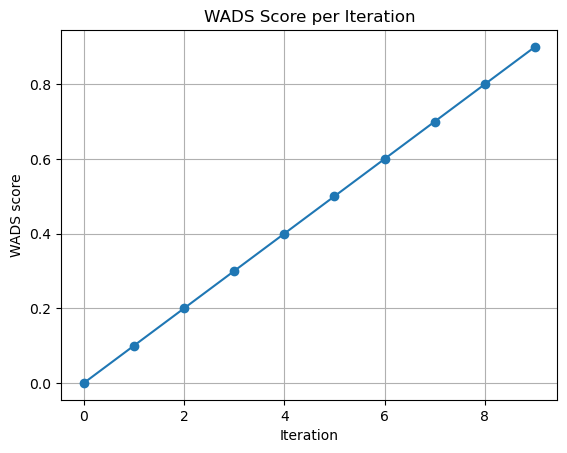

In [18]:
import matplotlib.pyplot as plt

# Number of iterations
num_iterations = 10

# Initialize scores list
scores = []

# Example loop (replace compute_wads with your actual function)
for i in range(num_iterations):
    score = i * 0.1   # placeholder value
    scores.append(score)

# Plot the scores
plt.figure()
plt.plot(range(len(scores)), scores, marker='o')
plt.xlabel('Iteration')
plt.ylabel('WADS score')
plt.title('WADS Score per Iteration')
plt.grid(True)
plt.show()


 ## 6. Define Anchors

 This step defines a set of anchor nodes and a penalty parameter that influence how strongly these nodes are constrained during optimization or learning.


In [19]:
anchors = {0, 1}   # important nodes
lambda_penalty = 0.5


## 7. Density Function (Anchored Density)

The anchored density function measures how strongly a selected set of nodes 
𝑆
S is connected internally, while penalizing the inclusion of non-anchor nodes.



In [20]:
def anchored_density(G, S, anchors, penalty):
    internal_weight = 0
    penalty_term = 0

    for u, v, data in G.edges(data=True):
        if u in S and v in S:
            internal_weight += data['weight']

    for v in S:
        if v not in anchors:
            penalty_term += G.degree(v, weight='weight')

    return (internal_weight - penalty * penalty_term) / len(S)

## 8. Greedy WADS Algorithm

The Greedy WADS algorithm builds a node set 
𝑆
S that (approximately) maximizes the Weighted Anchored Density Score (WADS).

In [22]:
def greedy_wads(G, anchors, penalty):
    S = set(G.nodes())
    best_S = S.copy()
    best_density = float('-inf')

    while len(S - anchors) > 0:
        current_density = anchored_density(G, S, anchors, penalty)

        if current_density > best_density:
            best_density = current_density
            best_S = S.copy()

        min_node = None
        min_value = float('inf')

        for v in S:
            if v in anchors:
                continue
            temp_S = S - {v}
            val = anchored_density(G, temp_S, anchors, penalty)
            if val < min_value:
                min_value = val
                min_node = v

        S.remove(min_node)

    return best_S, best_density